# Benchmark Split Preprocessing and Building-Crop Extraction

## Purpose

This notebook prepares the original xView2 benchmark split for the thesis baseline experiments. Its main purpose is to transform the original end-to-end xView2 data structure into a building-level classification dataset.

Instead of using the full competition pipeline, which includes both localization and classification, this notebook uses the ground-truth building polygons provided in the label JSON files to extract pre-event and post-event building crops. This allows the thesis to isolate the damage classification task.

## Motivation

The original xView2 pipeline evaluates an end-to-end system in which buildings must first be localized and then classified by damage level. For this thesis, the objective is different: the goal is to compare robustness strategies for damage classification under benchmark and location-based OOD evaluation.

Using ground-truth polygons removes localization errors as a confounding factor. As a result, differences in model performance can be attributed more directly to the classification model and the robustness strategy being evaluated.

## Main Tasks

* Read the original xView2 \texttt{train}, \texttt{test}, and \texttt{hold} folders
* Parse building polygons and damage labels from JSON annotation files
* Extract pre-event and post-event building crops
* Stack pre-event and post-event crops into 6-channel tensors
* Build a building-level metadata table
* Preserve the original benchmark split labels
* Generate the classification-only dataset used by the benchmark baseline

## Inputs

```text
train/
test/
hold/
```

Each folder contains:

* satellite image files
* label JSON files

## Outputs

```text
processed/buildings_all_with_crops.csv
```

This output contains one row per building instance, including:

* split label
* disaster identifier
* image identifier
* building identifier
* damage label
* polygon and bounding box information
* path to the extracted 6-channel building crop

The resulting dataset is used for the original benchmark baseline experiment and as the starting point for the location-based OOD split construction.


## Phase 1: Building-Level Dataset Construction



### Build metadata for training set

In [9]:
from pathlib import Path
import json
import pandas as pd
from shapely import wkt

split = "train"  

images_dir = Path.home() / "Desktop" / split / "images"
labels_dir = Path.home() / "Desktop" / split / "labels"
output_csv = Path.home() / "Desktop" / f"buildings_master_{split}.csv"
output_parquet = Path.home() / "Desktop" / f"buildings_master_{split}.parquet"

valid_labels = {"no-damage", "minor-damage", "major-damage", "destroyed"}

rows = []
json_files = sorted(labels_dir.glob("*_post_disaster.json"))

for json_path in json_files:
    image_id = json_path.stem.replace("_post_disaster", "")
    disaster = "_".join(image_id.split("_")[:-1])

    pre_image = images_dir / f"{image_id}_pre_disaster.png"
    post_image = images_dir / f"{image_id}_post_disaster.png"

    if not pre_image.exists() or not post_image.exists():
        print(f"Skipping {image_id}: missing pre or post image")
        continue

    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)
    except Exception as e:
        print(f"Skipping {json_path.name}: could not read JSON ({e})")
        continue

    features = data.get("features", {}).get("xy", [])
    if not isinstance(features, list):
        print(f"Skipping {json_path.name}: invalid features format")
        continue

    for building_index, feat in enumerate(features):
        props = feat.get("properties", {})
        poly_wkt = feat.get("wkt")

        if not poly_wkt:
            continue

        try:
            poly = wkt.loads(poly_wkt)
        except Exception:
            continue

        if poly.is_empty or not poly.is_valid:
            continue

        damage_label = props.get("subtype")
        if damage_label not in valid_labels:
            continue

        minx, miny, maxx, maxy = poly.bounds

        instance_id = f"{image_id}_{building_index}"
        building_uuid = props.get("uid")

        rows.append(
            {
                "instance_id": instance_id,
                "split": split,
                "disaster": disaster,
                "image_id": image_id,
                "pre_image_path": str(pre_image),
                "post_image_path": str(post_image),
                "label_json_path": str(json_path),
                "building_index": building_index,
                "building_uuid": building_uuid,
                "damage_label": damage_label,
                "wkt": poly_wkt,
                "xmin": float(minx),
                "ymin": float(miny),
                "xmax": float(maxx),
                "ymax": float(maxy),
                "bbox_width": float(maxx - minx),
                "bbox_height": float(maxy - miny),
            }
        )

df = pd.DataFrame(rows)

if df.empty:
    print(f"No valid building instances found for split: {split}")
else:
    df = df.sort_values(["disaster", "image_id", "building_index"]).reset_index(drop=True)

    df.to_csv(output_csv, index=False)
    print(f"Saved {len(df)} buildings to {output_csv}")

    try:
        df.to_parquet(output_parquet, index=False)
        print(f"Saved {len(df)} buildings to {output_parquet}")
    except ImportError:
        print(
            "Parquet file not saved because neither 'pyarrow' nor 'fastparquet' is installed. "
            "CSV export completed successfully."
        )

    print("\nDamage label distribution:")
    print(df["damage_label"].value_counts(dropna=False))

    print("\nUnique labels kept:")
    print(sorted(df["damage_label"].dropna().unique()))

Saved 159793 buildings to /Users/paolo/Desktop/buildings_master_train.csv
Parquet file not saved because neither 'pyarrow' nor 'fastparquet' is installed. CSV export completed successfully.

Damage label distribution:
damage_label
no-damage       117425
minor-damage     14980
major-damage     14161
destroyed        13227
Name: count, dtype: int64

Unique labels kept:
['destroyed', 'major-damage', 'minor-damage', 'no-damage']


### Build metadata for test (validation) set

In [10]:
from pathlib import Path
import json
import pandas as pd
from shapely import wkt

split = "test"  

images_dir = Path.home() / "Desktop" / split / "images"
labels_dir = Path.home() / "Desktop" / split / "labels"
output_csv = Path.home() / "Desktop" / f"buildings_master_{split}.csv"
output_parquet = Path.home() / "Desktop" / f"buildings_master_{split}.parquet"

valid_labels = {"no-damage", "minor-damage", "major-damage", "destroyed"}

rows = []
json_files = sorted(labels_dir.glob("*_post_disaster.json"))

for json_path in json_files:
    image_id = json_path.stem.replace("_post_disaster", "")
    disaster = "_".join(image_id.split("_")[:-1])

    pre_image = images_dir / f"{image_id}_pre_disaster.png"
    post_image = images_dir / f"{image_id}_post_disaster.png"

    if not pre_image.exists() or not post_image.exists():
        print(f"Skipping {image_id}: missing pre or post image")
        continue

    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)
    except Exception as e:
        print(f"Skipping {json_path.name}: could not read JSON ({e})")
        continue

    features = data.get("features", {}).get("xy", [])
    if not isinstance(features, list):
        print(f"Skipping {json_path.name}: invalid features format")
        continue

    for building_index, feat in enumerate(features):
        props = feat.get("properties", {})
        poly_wkt = feat.get("wkt")

        if not poly_wkt:
            continue

        try:
            poly = wkt.loads(poly_wkt)
        except Exception:
            continue

        if poly.is_empty or not poly.is_valid:
            continue

        damage_label = props.get("subtype")
        if damage_label not in valid_labels:
            continue

        minx, miny, maxx, maxy = poly.bounds

        instance_id = f"{image_id}_{building_index}"
        building_uuid = props.get("uid")

        rows.append(
            {
                "instance_id": instance_id,
                "split": split,
                "disaster": disaster,
                "image_id": image_id,
                "pre_image_path": str(pre_image),
                "post_image_path": str(post_image),
                "label_json_path": str(json_path),
                "building_index": building_index,
                "building_uuid": building_uuid,
                "damage_label": damage_label,
                "wkt": poly_wkt,
                "xmin": float(minx),
                "ymin": float(miny),
                "xmax": float(maxx),
                "ymax": float(maxy),
                "bbox_width": float(maxx - minx),
                "bbox_height": float(maxy - miny),
            }
        )

df = pd.DataFrame(rows)

if df.empty:
    print(f"No valid building instances found for split: {split}")
else:
    df = df.sort_values(["disaster", "image_id", "building_index"]).reset_index(drop=True)

    df.to_csv(output_csv, index=False)
    print(f"Saved {len(df)} buildings to {output_csv}")

    try:
        df.to_parquet(output_parquet, index=False)
        print(f"Saved {len(df)} buildings to {output_parquet}")
    except ImportError:
        print(
            "Parquet file not saved because neither 'pyarrow' nor 'fastparquet' is installed. "
            "CSV export completed successfully."
        )

    print("\nDamage label distribution:")
    print(df["damage_label"].value_counts(dropna=False))

    print("\nUnique labels kept:")
    print(sorted(df["damage_label"].dropna().unique()))

Saved 53850 buildings to /Users/paolo/Desktop/buildings_master_test.csv
Parquet file not saved because neither 'pyarrow' nor 'fastparquet' is installed. CSV export completed successfully.

Damage label distribution:
damage_label
no-damage       41427
minor-damage     4798
major-damage     3850
destroyed        3775
Name: count, dtype: int64

Unique labels kept:
['destroyed', 'major-damage', 'minor-damage', 'no-damage']


### Build metadata for holdout (final test) set

In [11]:
from pathlib import Path
import json
import pandas as pd
from shapely import wkt

split = "hold"  

images_dir = Path.home() / "Desktop" / split / "images"
labels_dir = Path.home() / "Desktop" / split / "labels"
output_csv = Path.home() / "Desktop" / f"buildings_master_{split}.csv"
output_parquet = Path.home() / "Desktop" / f"buildings_master_{split}.parquet"

valid_labels = {"no-damage", "minor-damage", "major-damage", "destroyed"}

rows = []
json_files = sorted(labels_dir.glob("*_post_disaster.json"))

for json_path in json_files:
    image_id = json_path.stem.replace("_post_disaster", "")
    disaster = "_".join(image_id.split("_")[:-1])

    pre_image = images_dir / f"{image_id}_pre_disaster.png"
    post_image = images_dir / f"{image_id}_post_disaster.png"

    if not pre_image.exists() or not post_image.exists():
        print(f"Skipping {image_id}: missing pre or post image")
        continue

    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)
    except Exception as e:
        print(f"Skipping {json_path.name}: could not read JSON ({e})")
        continue

    features = data.get("features", {}).get("xy", [])
    if not isinstance(features, list):
        print(f"Skipping {json_path.name}: invalid features format")
        continue

    for building_index, feat in enumerate(features):
        props = feat.get("properties", {})
        poly_wkt = feat.get("wkt")

        if not poly_wkt:
            continue

        try:
            poly = wkt.loads(poly_wkt)
        except Exception:
            continue

        if poly.is_empty or not poly.is_valid:
            continue

        damage_label = props.get("subtype")
        if damage_label not in valid_labels:
            continue

        minx, miny, maxx, maxy = poly.bounds

        instance_id = f"{image_id}_{building_index}"
        building_uuid = props.get("uid")

        rows.append(
            {
                "instance_id": instance_id,
                "split": split,
                "disaster": disaster,
                "image_id": image_id,
                "pre_image_path": str(pre_image),
                "post_image_path": str(post_image),
                "label_json_path": str(json_path),
                "building_index": building_index,
                "building_uuid": building_uuid,
                "damage_label": damage_label,
                "wkt": poly_wkt,
                "xmin": float(minx),
                "ymin": float(miny),
                "xmax": float(maxx),
                "ymax": float(maxy),
                "bbox_width": float(maxx - minx),
                "bbox_height": float(maxy - miny),
            }
        )

df = pd.DataFrame(rows)

if df.empty:
    print(f"No valid building instances found for split: {split}")
else:
    df = df.sort_values(["disaster", "image_id", "building_index"]).reset_index(drop=True)

    df.to_csv(output_csv, index=False)
    print(f"Saved {len(df)} buildings to {output_csv}")

    try:
        df.to_parquet(output_parquet, index=False)
        print(f"Saved {len(df)} buildings to {output_parquet}")
    except ImportError:
        print(
            "Parquet file not saved because neither 'pyarrow' nor 'fastparquet' is installed. "
            "CSV export completed successfully."
        )

    print("\nDamage label distribution:")
    print(df["damage_label"].value_counts(dropna=False))

    print("\nUnique labels kept:")
    print(sorted(df["damage_label"].dropna().unique()))

Saved 53137 buildings to /Users/paolo/Desktop/buildings_master_hold.csv
Parquet file not saved because neither 'pyarrow' nor 'fastparquet' is installed. CSV export completed successfully.

Damage label distribution:
damage_label
no-damage       37971
minor-damage     6338
major-damage     4605
destroyed        4223
Name: count, dtype: int64

Unique labels kept:
['destroyed', 'major-damage', 'minor-damage', 'no-damage']


### Merge sets

In [12]:
import pandas as pd
from pathlib import Path

base = Path.home() / "Desktop"

df_train = pd.read_csv(base / "buildings_master_train.csv")
df_test = pd.read_csv(base / "buildings_master_test.csv")
df_holdout = pd.read_csv(base / "buildings_master_hold.csv")

df_all = pd.concat([df_train, df_test, df_holdout], ignore_index=True)

### Sanity checks

Split

In [13]:
print(df_all["split"].value_counts())

split
train    159793
test      53850
hold      53137
Name: count, dtype: int64


data leakage check

In [14]:
train_ids = set(df_train["image_id"])
test_ids = set(df_test["image_id"])
holdout_ids = set(df_holdout["image_id"])

print("train ∩ test:", len(train_ids & test_ids))
print("train ∩ holdout:", len(train_ids & holdout_ids))
print("test ∩ holdout:", len(test_ids & holdout_ids))

train ∩ test: 0
train ∩ holdout: 0
test ∩ holdout: 0


Final .csv

In [15]:
df_all.to_csv(base / "buildings_all.csv", index=False)



# Phase 2: Crop Extraction and Input Construction


In [16]:
from pathlib import Path
import pandas as pd
import numpy as np
import cv2

# Paths
base_dir = Path.home() / "Desktop"
input_csv = base_dir / "buildings_all.csv"
output_dir = base_dir / "processed"
output_csv = output_dir / "buildings_all_with_crops.csv"

# Separate crop folders by split
crop_root = output_dir / "crops_np"
for split_name in ["train", "test", "hold"]:
    (crop_root / split_name).mkdir(parents=True, exist_ok=True)

# Load merged metadata
df = pd.read_csv(input_csv)

rows = []

# Process by image_id so each pre/post image is loaded only once
group_cols = ["split", "image_id", "pre_image_path", "post_image_path"]
grouped = df.groupby(group_cols, sort=False)

for group_idx, ((split, image_id, pre_path, post_path), group_df) in enumerate(grouped, start=1):
    pre_img = cv2.imread(str(pre_path))
    post_img = cv2.imread(str(post_path))

    if pre_img is None or post_img is None:
        print(f"Skipping image_id={image_id}: could not load pre or post image")
        continue

    for _, row in group_df.iterrows():
        try:
            xmin, ymin, xmax, ymax = row["xmin"], row["ymin"], row["xmax"], row["ymax"]

            x0 = max(0, int(np.floor(xmin)))
            y0 = max(0, int(np.floor(ymin)))
            x1 = min(pre_img.shape[1], int(np.ceil(xmax)))
            y1 = min(pre_img.shape[0], int(np.ceil(ymax)))

            if x1 <= x0 or y1 <= y0:
                continue

            pre_crop = pre_img[y0:y1, x0:x1]
            post_crop = post_img[y0:y1, x0:x1]

            if pre_crop.size == 0 or post_crop.size == 0:
                continue

            # Resize to fixed size
            size = 128
            pre_crop = cv2.resize(pre_crop, (size, size), interpolation=cv2.INTER_LINEAR)
            post_crop = cv2.resize(post_crop, (size, size), interpolation=cv2.INTER_LINEAR)

            # Stack into 6 channels: pre RGB + post RGB
            stacked = np.concatenate([pre_crop, post_crop], axis=2)

            save_path = crop_root / split / f"{row['instance_id']}.npy"

            # Save only if not already present
            if not save_path.exists():
                np.save(save_path, stacked)

            new_row = row.to_dict()
            new_row["crop_path"] = str(save_path)

            rows.append(new_row)

        except Exception as e:
            print(f"Skipping instance_id={row['instance_id']}: {e}")
            continue

    if group_idx % 100 == 0:
        print(f"Processed {group_idx} image groups")

df_out = pd.DataFrame(rows)

# Optional sort for readability
sort_cols = [c for c in ["split", "disaster", "image_id", "building_index"] if c in df_out.columns]
if not df_out.empty:
    df_out = df_out.sort_values(sort_cols).reset_index(drop=True)

output_dir.mkdir(parents=True, exist_ok=True)
df_out.to_csv(output_csv, index=False)

print(f"Saved {len(df_out)} crops metadata rows to {output_csv}")
print(df_out["split"].value_counts(dropna=False))

Processed 100 image groups
Processed 200 image groups
Processed 300 image groups
Processed 400 image groups
Processed 500 image groups
Processed 600 image groups
Processed 700 image groups
Processed 800 image groups
Processed 900 image groups
Processed 1000 image groups
Processed 1100 image groups
Processed 1200 image groups
Processed 1300 image groups
Processed 1400 image groups
Processed 1500 image groups
Processed 1600 image groups
Processed 1700 image groups
Processed 1800 image groups
Processed 1900 image groups
Processed 2000 image groups
Processed 2100 image groups
Processed 2200 image groups
Processed 2300 image groups
Processed 2400 image groups
Processed 2500 image groups
Processed 2600 image groups
Processed 2700 image groups
Processed 2800 image groups
Processed 2900 image groups
Processed 3000 image groups
Processed 3100 image groups
Processed 3200 image groups
Processed 3300 image groups
Processed 3400 image groups
Processed 3500 image groups
Processed 3600 image groups
P

In [17]:
import pandas as pd
from pathlib import Path

df = pd.read_csv(Path.home() / "Desktop" / "processed" / "buildings_all_with_crops.csv")
print(df["split"].value_counts())
print(df["damage_label"].value_counts())
print(df.head(2))

split
train    159793
test      53850
hold      53137
Name: count, dtype: int64
damage_label
no-damage       196823
minor-damage     26116
major-damage     22616
destroyed        21225
Name: count, dtype: int64
                    instance_id split           disaster  \
0  guatemala-volcano_00000004_0  hold  guatemala-volcano   
1  guatemala-volcano_00000004_1  hold  guatemala-volcano   

                     image_id  \
0  guatemala-volcano_00000004   
1  guatemala-volcano_00000004   

                                      pre_image_path  \
0  /Users/paolo/Desktop/hold/images/guatemala-vol...   
1  /Users/paolo/Desktop/hold/images/guatemala-vol...   

                                     post_image_path  \
0  /Users/paolo/Desktop/hold/images/guatemala-vol...   
1  /Users/paolo/Desktop/hold/images/guatemala-vol...   

                                     label_json_path  building_index  \
0  /Users/paolo/Desktop/hold/labels/guatemala-vol...               0   
1  /Users/paolo/Desktop/ho

## Sanity Checks on Extracted Building Crops


In [18]:
from pathlib import Path
import pandas as pd
import numpy as np

# Paths
base_dir = Path.home() / "Desktop"
input_csv = base_dir / "processed" / "buildings_all_with_crops.csv"

# Load dataset
df = pd.read_csv(input_csv)

# Replicable selection:
# sort deterministically, then take the first row
df = df.sort_values(["split", "disaster", "image_id", "building_index"]).reset_index(drop=True)
row = df.iloc[0]

# Load crop
crop_path = Path(row["crop_path"])
x = np.load(crop_path)

print("instance_id:", row["instance_id"])
print("split:", row["split"])
print("damage_label:", row["damage_label"])
print("crop_path:", crop_path)
print("shape:", x.shape)
print("dtype:", x.dtype)
print("min/max:", x.min(), x.max())

instance_id: guatemala-volcano_00000004_0
split: hold
damage_label: major-damage
crop_path: /Users/paolo/Desktop/processed/crops_np/hold/guatemala-volcano_00000004_0.npy
shape: (128, 128, 6)
dtype: uint8
min/max: 10 202




## Replicable Visual Sanity Check of Pre and Post Disaster Crops



=== TRAIN ===
instance_id: guatemala-volcano_00000000_0
damage_label: no-damage
crop_path: /Users/paolo/Desktop/processed/crops_np/train/guatemala-volcano_00000000_0.npy
shape: (128, 128, 6)
dtype: uint8
min/max: 16 246


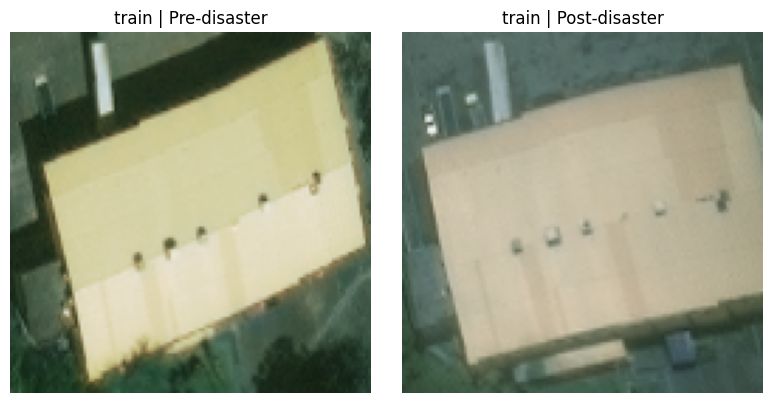


=== TEST ===
instance_id: guatemala-volcano_00000003_0
damage_label: minor-damage
crop_path: /Users/paolo/Desktop/processed/crops_np/test/guatemala-volcano_00000003_0.npy
shape: (128, 128, 6)
dtype: uint8
min/max: 12 255


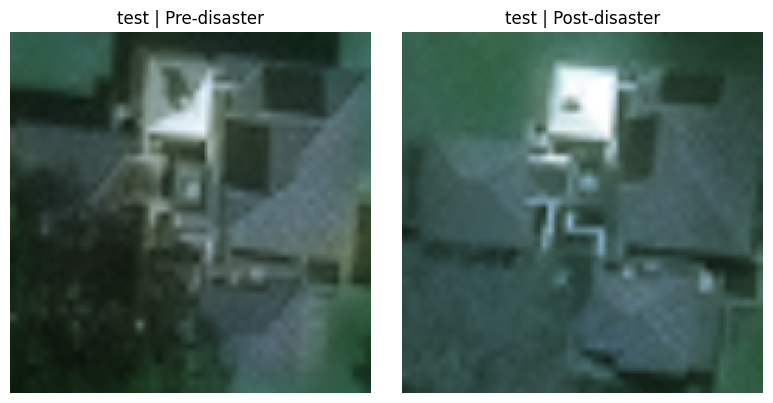


=== HOLD ===
instance_id: guatemala-volcano_00000004_0
damage_label: major-damage
crop_path: /Users/paolo/Desktop/processed/crops_np/hold/guatemala-volcano_00000004_0.npy
shape: (128, 128, 6)
dtype: uint8
min/max: 10 202


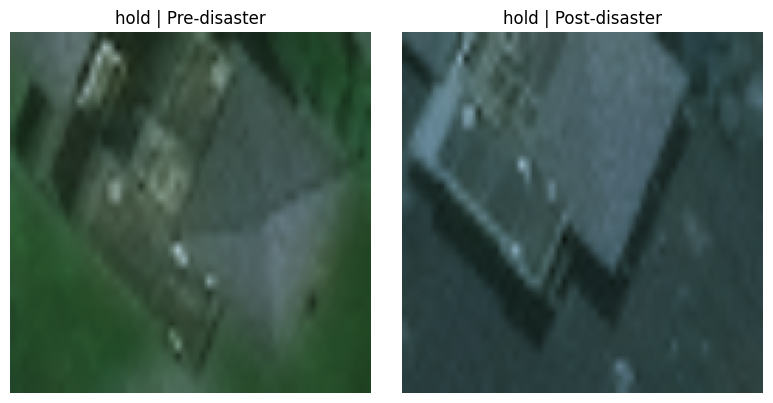

In [19]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Paths
base_dir = Path.home() / "Desktop"
input_csv = base_dir / "processed" / "buildings_all_with_crops.csv"

# Load dataset
df = pd.read_csv(input_csv)

# Deterministic selection
df = df.sort_values(["split", "disaster", "image_id", "building_index"]).reset_index(drop=True)

# Pick one sample per split
for split_name in ["train", "test", "hold"]:
    subset = df[df["split"] == split_name].reset_index(drop=True)

    if subset.empty:
        print(f"\nNo rows found for split: {split_name}")
        continue

    row = subset.iloc[0]
    x = np.load(row["crop_path"])

    print(f"\n=== {split_name.upper()} ===")
    print("instance_id:", row["instance_id"])
    print("damage_label:", row["damage_label"])
    print("crop_path:", row["crop_path"])
    print("shape:", x.shape)
    print("dtype:", x.dtype)
    print("min/max:", x.min(), x.max())

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].imshow(x[:, :, :3].astype("uint8"))
    axes[0].set_title(f"{split_name} | Pre-disaster")
    axes[0].axis("off")

    axes[1].imshow(x[:, :, 3:].astype("uint8"))
    axes[1].set_title(f"{split_name} | Post-disaster")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

Minor spatial misalignments between pre- and post-disaster crops are observed due to differences in satellite acquisition conditions. These are expected and do not affect the validity of the classification task, as the model is designed to learn robust representations rather than rely on pixel-level alignment.